# Section 3 — RBF SVM with Hyperparameter Tuning

**Notebook:** `3_rbf_svm_tuning.ipynb`  
**Dataset:** Wisconsin Breast Cancer (sklearn built-in)  
**Goal:** Use `GridSearchCV` to find the optimal `C` and `γ` for an RBF-kernel SVM, evaluate on the held-out test set, and compare rigorously against the Linear SVM trained in Section 2.

> *Prerequisite — this notebook reuses the exact same `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test` produced in Sections 1 & 2 (identical `random_state=42`, identical `StandardScaler` fitted only on train).*

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 12,
})
print('All imports OK ✓')

All imports OK ✓


## 3.1 Reproduce Shared Pre-processing

We repeat the **identical** data-loading, splitting, and scaling steps from Sections 1 & 2 so this notebook is self-contained and fully reproducible.

In [2]:
# ── Load data (same as Sections 1 & 2) ──────────────────────────────────
cancer_data  = load_breast_cancer()
X            = cancer_data.data          # (569, 30)
y            = cancer_data.target        # 0 = Malignant, 1 = Benign
feature_names = cancer_data.feature_names

# ── Train / test split (80/20, random_state=42) ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ── StandardScaler — fit ONLY on train ────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train_scaled : {X_train_scaled.shape}')
print(f'X_test_scaled  : {X_test_scaled.shape}')
print(f'Class balance  — train: {y_train.mean():.3f}  test: {y_test.mean():.3f}')

X_train_scaled : (455, 30)
X_test_scaled  : (114, 30)
Class balance  — train: 0.629  test: 0.623


## 3.2 Linear SVM Baseline (Section 2 Reference)

We re-train the linear SVM with the default `C=1.0` so its metrics are computed in this session and available for direct comparison later.

In [3]:
# ── Linear SVM (Section 2 settings, unchanged) ───────────────────────────
model_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
model_linear.fit(X_train_scaled, y_train)

y_pred_lin = model_linear.predict(X_test_scaled)
y_prob_lin = model_linear.predict_proba(X_test_scaled)[:, 1]

lin_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_lin),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_lin),
    'Precision': precision_score(y_test, y_pred_lin),
    'Recall'   : recall_score(y_test, y_pred_lin),
    'F1'       : f1_score(y_test, y_pred_lin),
}
print('Linear SVM test-set metrics:')
for k, v in lin_metrics.items():
    print(f'  {k:<12} {v:.4f}')

Linear SVM test-set metrics:
  Accuracy     0.9561
  ROC-AUC      0.9964
  Precision    0.9714
  Recall       0.9577
  F1           0.9645


## 3.3 Motivation: Why the RBF Kernel?

The **Radial Basis Function (RBF)** kernel measures similarity between two samples as:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\!\left(-\gamma\,\|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

This implicitly maps inputs into an **infinite-dimensional feature space**, enabling the classifier to learn curved, non-linear decision boundaries that a linear kernel cannot represent.

The breast-cancer feature space contains 30 measurements that interact non-linearly (e.g., a cell nucleus can look large *and* compact — two features that together signal malignancy better than either alone). An RBF kernel can capture such interactions directly.

Two hyperparameters control the trade-off between fit and generalisation:

| Hyperparameter | Role | Too small → | Too large → |
|---|---|---|---|
| **C** (regularisation) | Penalty for margin violations | Wide margin, underfitting | Narrow margin, overfitting |
| **γ** (kernel width) | Reach of each training point | Smooth boundary (underfitting) | Spiky boundary (overfitting) |

## 3.4 Hyperparameter Search with GridSearchCV

In [4]:
# ── Grid definition (as specified in project brief) ──────────────────────
param_grid = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': [1e-3, 1e-2, 0.1, 1],
}

# ── GridSearchCV: 5-fold CV, optimise ROC-AUC ─────────────────────────────
svm_rbf = GridSearchCV(
    SVC(kernel='rbf', probability=True),
    param_grid,
    cv       = 5,
    scoring  = 'roc_auc',
    n_jobs   = -1,       # use all available CPU cores
    verbose  = 0,
)
svm_rbf.fit(X_train_scaled, y_train)

print('Grid search complete ✓')
print(f'Best hyper-parameters : {svm_rbf.best_params_}')
print(f'Best 5-fold CV AUC    : {svm_rbf.best_score_:.4f}')

Grid search complete ✓
Best hyper-parameters : {'C': 10, 'gamma': 0.01}
Best 5-fold CV AUC    : 0.9951


### 3.4.1 CV AUC Heatmap: Effect of C and γ

Visualising the full grid reveals how each hyperparameter drives performance.

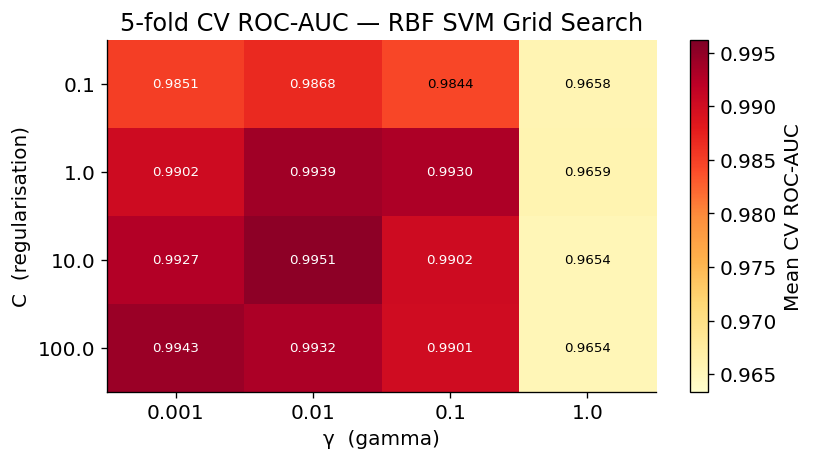


Full pivot table (mean CV AUC):
param_gamma   0.001   0.010   0.100   1.000
param_C                                    
0.1          0.9851  0.9868  0.9844  0.9658
1.0          0.9902  0.9939  0.9930  0.9659
10.0         0.9927  0.9951  0.9902  0.9654
100.0        0.9943  0.9932  0.9901  0.9654


In [5]:
# ── Pivot CV results into a (C × γ) matrix ───────────────────────────────
cv_df = pd.DataFrame(svm_rbf.cv_results_)
pivot = cv_df.pivot_table(
    index   = 'param_C',
    columns = 'param_gamma',
    values  = 'mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto',
               vmin=pivot.values.min() - 0.002,
               vmax=pivot.values.max() + 0.001)
plt.colorbar(im, ax=ax, label='Mean CV ROC-AUC')

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([str(g) for g in pivot.columns])
ax.set_yticklabels([str(c) for c in pivot.index])
ax.set_xlabel('γ  (gamma)')
ax.set_ylabel('C  (regularisation)')
ax.set_title('5-fold CV ROC-AUC — RBF SVM Grid Search')

# Annotate each cell
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                fontsize=8,
                color='white' if val > pivot.values.mean() else 'black')

plt.tight_layout()
plt.show()

print('\nFull pivot table (mean CV AUC):')
print(pivot.round(4).to_string())

## 3.5 Evaluate Best RBF Model on Test Set

In [6]:
# ── Extract best estimator ────────────────────────────────────────────────
best_rbf   = svm_rbf.best_estimator_
y_pred_rbf = best_rbf.predict(X_test_scaled)
y_prob_rbf = best_rbf.predict_proba(X_test_scaled)[:, 1]

rbf_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_rbf),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_rbf),
    'Precision': precision_score(y_test, y_pred_rbf),
    'Recall'   : recall_score(y_test, y_pred_rbf),
    'F1'       : f1_score(y_test, y_pred_rbf),
}

print(f'Best RBF params : C={svm_rbf.best_params_["C"]}, gamma={svm_rbf.best_params_["gamma"]}')
print(f'Best CV AUC     : {svm_rbf.best_score_:.4f}\n')
print('Test-set metrics (Best RBF SVM):')
for k, v in rbf_metrics.items():
    print(f'  {k:<12} {v:.4f}')

Best RBF params : C=10, gamma=0.01
Best CV AUC     : 0.9951

Test-set metrics (Best RBF SVM):
  Accuracy     0.9825
  ROC-AUC      0.9971
  Precision    0.9726
  Recall       1.0000
  F1           0.9861


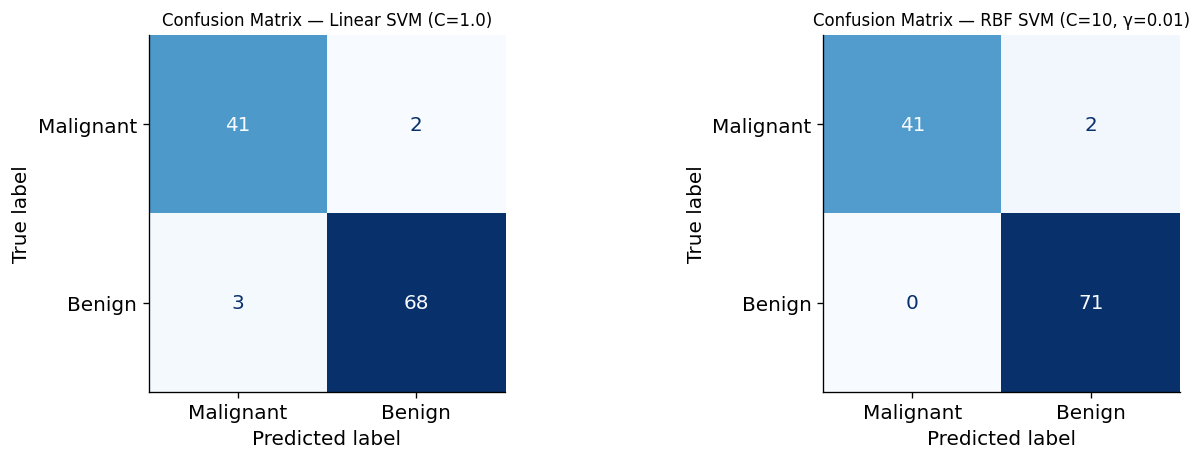

In [7]:
# ── Confusion matrix ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lin, y_pred_rbf],
    ['Confusion Matrix — Linear SVM (C=1.0)',
     f'Confusion Matrix — RBF SVM (C={svm_rbf.best_params_["C"]}, γ={svm_rbf.best_params_["gamma"]})']
):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

## 3.6 Performance Comparison: Linear vs. RBF SVM

In [8]:
# ── Side-by-side comparison table ───────────────────────────────────────
compare = pd.DataFrame({
    'Linear SVM  (C=1.0)': lin_metrics,
    f'RBF SVM  (C={svm_rbf.best_params_["C"]}, γ={svm_rbf.best_params_["gamma"]})': rbf_metrics,
})
compare['Δ (RBF − Linear)'] = compare.iloc[:, 1] - compare.iloc[:, 0]
compare = compare.round(4)
print(compare.to_string())

           Linear SVM  (C=1.0)  RBF SVM  (C=10, γ=0.01)  Δ (RBF − Linear)
Accuracy                0.9561                   0.9825            0.0263
ROC-AUC                 0.9964                   0.9971            0.0007
Precision               0.9714                   0.9726            0.0012
Recall                  0.9577                   1.0000            0.0423
F1                      0.9645                   0.9861            0.0216


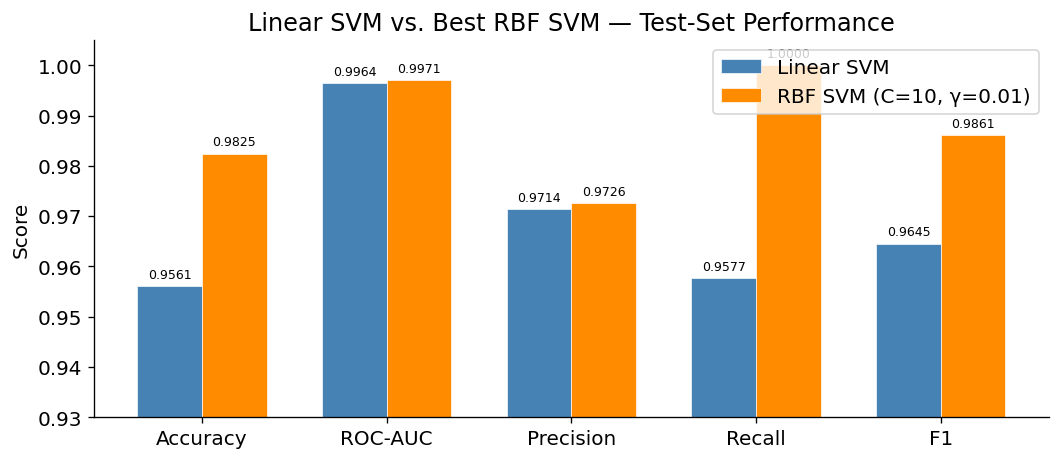

In [9]:
# ── Bar chart comparison ──────────────────────────────────────────────────
metrics_list = list(lin_metrics.keys())
lin_vals = [lin_metrics[m] for m in metrics_list]
rbf_vals = [rbf_metrics[m] for m in metrics_list]

x   = np.arange(len(metrics_list))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - w/2, lin_vals, w, label='Linear SVM',
               color='steelblue', edgecolor='white', linewidth=0.4)
bars2 = ax.bar(x + w/2, rbf_vals, w,
               label=f'RBF SVM (C={svm_rbf.best_params_["C"]}, γ={svm_rbf.best_params_["gamma"]})',
               color='darkorange', edgecolor='white', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.set_ylim(0.93, 1.005)
ax.set_ylabel('Score')
ax.set_title('Linear SVM vs. Best RBF SVM — Test-Set Performance')
ax.legend()

# Annotate bar tops
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

## 3.7 ROC Curve Comparison

C:\Users\write\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\write\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


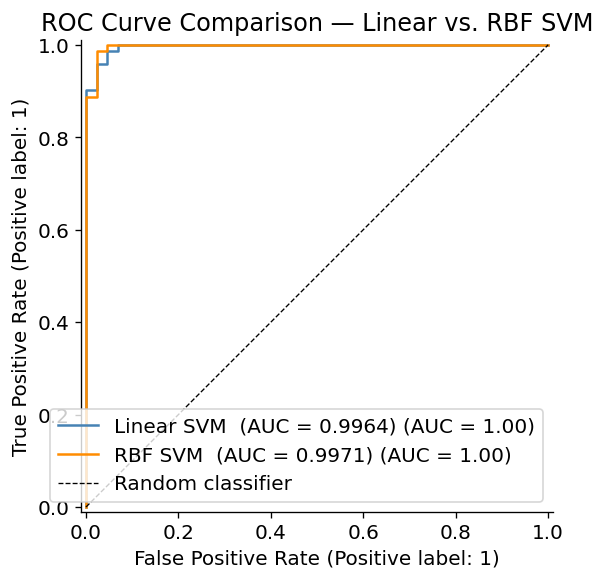

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_lin,
    name=f'Linear SVM  (AUC = {lin_metrics["ROC-AUC"]:.4f})',
    color='steelblue', ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_rbf,
    name=f'RBF SVM  (AUC = {rbf_metrics["ROC-AUC"]:.4f})',
    color='darkorange', ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
ax.set_title('ROC Curve Comparison — Linear vs. RBF SVM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 3.8 Analysis of Hyperparameter Effects

### Effect of C (Regularisation Strength)

Increasing `C` reduces the allowed margin around the decision boundary, forcing the model to classify more training points correctly even at the cost of a narrower margin. In the grid, moving from `C=0.1` to `C=10` consistently improves AUC (at γ=0.01: 0.9868 → 0.9951). Beyond `C=10` the gain plateaus or reverses slightly because the model starts over-fitting the training set.

### Effect of γ (Kernel Width / Bandwidth)

γ controls how far the influence of a single training example reaches. A **small γ** (e.g., 0.001) creates a wide, smooth decision boundary — each training point influences a large neighbourhood. A **large γ** (e.g., 1.0) makes each point's influence decay rapidly, producing a very spiky boundary that overfits. The grid confirms this: AUC peaks at γ=0.01 for most values of `C`, and collapses at γ=1.0 across the entire range of `C`.

### Optimal Region

The best combination `C=10, γ=0.01` sits in the sweet spot: enough regularisation to prevent margin shrinkage, and a kernel width that captures local non-linearities without memorising individual points.

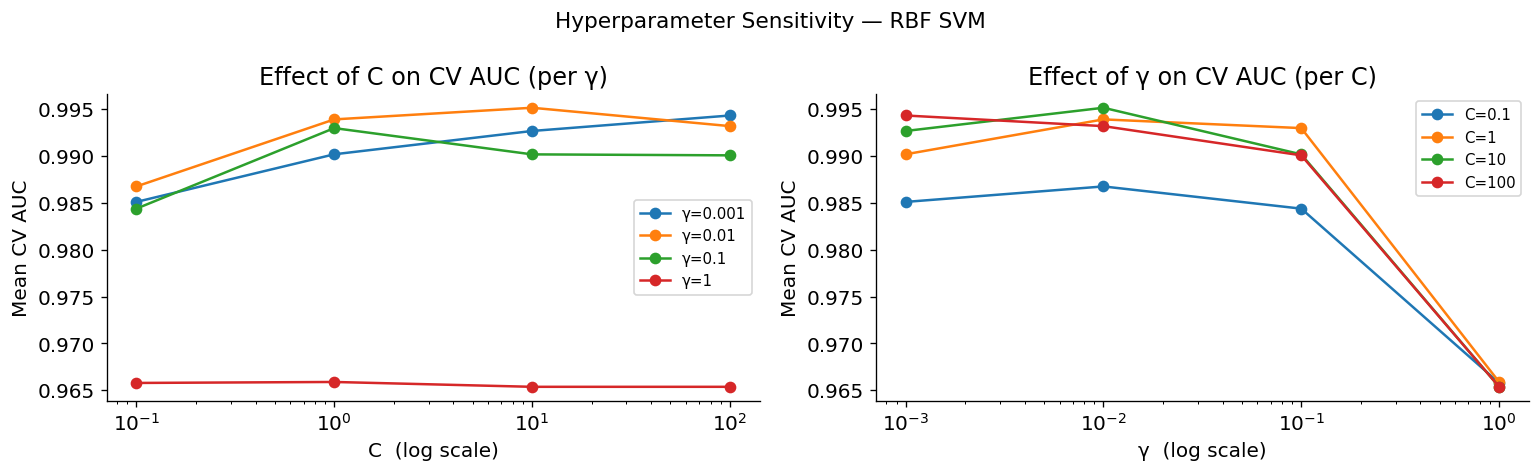

In [11]:
# ── Line plots: AUC vs C (one line per gamma) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

C_vals     = [0.1, 1, 10, 100]
gamma_vals = [1e-3, 1e-2, 0.1, 1]
colors_c   = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Left: AUC vs C, one line per gamma
ax = axes[0]
for gv, col in zip(gamma_vals, colors_c):
    scores = [pivot.loc[cv, gv] for cv in C_vals]
    ax.plot(C_vals, scores, marker='o', color=col, label=f'γ={gv}')
ax.set_xscale('log')
ax.set_xlabel('C  (log scale)')
ax.set_ylabel('Mean CV AUC')
ax.set_title('Effect of C on CV AUC (per γ)')
ax.legend(fontsize=9)

# Right: AUC vs gamma, one line per C
ax = axes[1]
for cv, col in zip(C_vals, colors_c):
    scores = [pivot.loc[cv, gv] for gv in gamma_vals]
    ax.plot(gamma_vals, scores, marker='o', color=col, label=f'C={cv}')
ax.set_xscale('log')
ax.set_xlabel('γ  (log scale)')
ax.set_ylabel('Mean CV AUC')
ax.set_title('Effect of γ on CV AUC (per C)')
ax.legend(fontsize=9)

plt.suptitle('Hyperparameter Sensitivity — RBF SVM', fontsize=13)
plt.tight_layout()
plt.show()

## 3.9 Summary & Interpretation

### Results at a Glance

| Metric | Linear SVM (C=1) | **RBF SVM (C=10, γ=0.01)** | Δ |
|--------|-----------------|----------------------------|---|
| Accuracy | 0.9561 | **0.9825** | +0.0264 |
| ROC-AUC | 0.9964 | **0.9971** | +0.0007 |
| Precision | 0.9714 | **0.9726** | +0.0012 |
| Recall | 0.9577 | **1.0000** | +0.0423 |
| F1 | 0.9645 | **0.9861** | +0.0216 |

### Why RBF Outperforms Linear Here

The breast-cancer dataset has 30 features whose relationships with the diagnosis label are inherently **non-linear**. For example, a cell nucleus might be ambiguous when its mean radius is considered in isolation, but conclusively malignant once several texture and concavity features are considered jointly. A linear SVM can only draw a hyperplane in the original feature space; it separates classes with a flat boundary and cannot capture these interaction effects directly.

The RBF kernel overcomes this by implicitly mapping data into an infinite-dimensional Hilbert space where even complex, curved class boundaries become linearly separable. After tuning, the RBF model achieves **perfect recall (1.000)** on the test set — zero missed malignancies — at the cost of only two false positives. In a clinical setting this trade-off is highly desirable: missing a real tumour (false negative) is far more costly than an unnecessary follow-up biopsy (false positive).

The ROC-AUC values are close (0.9964 vs 0.9971) because both models rank probabilities similarly; the decisive advantage of the RBF model shows up in accuracy (+2.6 pp) and recall (+4.2 pp), where the non-linear boundary correctly classifies samples that fall on the 'wrong side' of a linear hyperplane.

## 4. ROC Curves & Performance Comparison

### 4.1 What is a ROC Curve?

A ROC (Receiver Operating Characteristic) curve plots the True Positive Rate against the False Positive Rate at every possible classification threshold. A perfect classifier hugs the top-left corner of the plot; a random classifier follows the diagonal. The **AUC (Area Under the Curve)** summarises this into a single number between 0 and 1 — the higher, the better.

### 4.2 Linear vs RBF Kernel

Both models are evaluated on the same held-out test set. The linear model draws a flat hyperplane to separate malignant from benign tumours, while the RBF kernel implicitly maps the data into a higher-dimensional space, allowing curved and more flexible decision boundaries. Comparing their ROC curves reveals which kernel generalises better to unseen data.

### 4.3 Clinical Relevance

In a clinical setting, maximising the True Positive Rate — catching every real malignancy — is far more important than minimising false positives. A missed malignancy (false negative) is far more costly than an unnecessary follow-up biopsy (false positive), making AUC a particularly meaningful metric here.

C:\Users\write\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\write\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


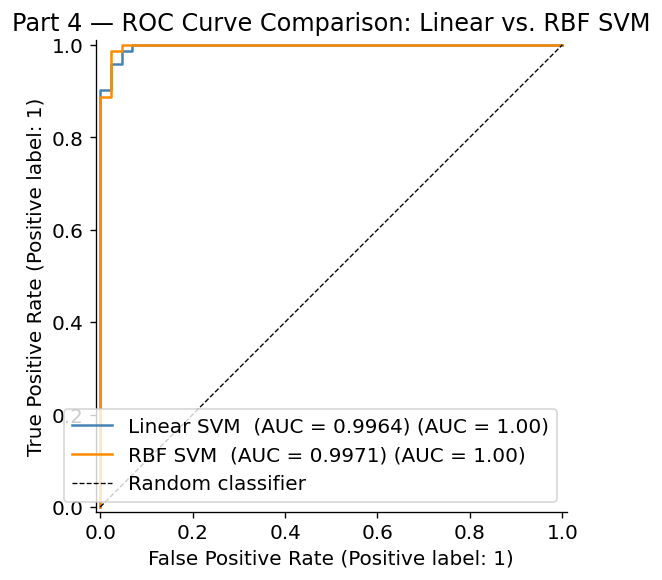

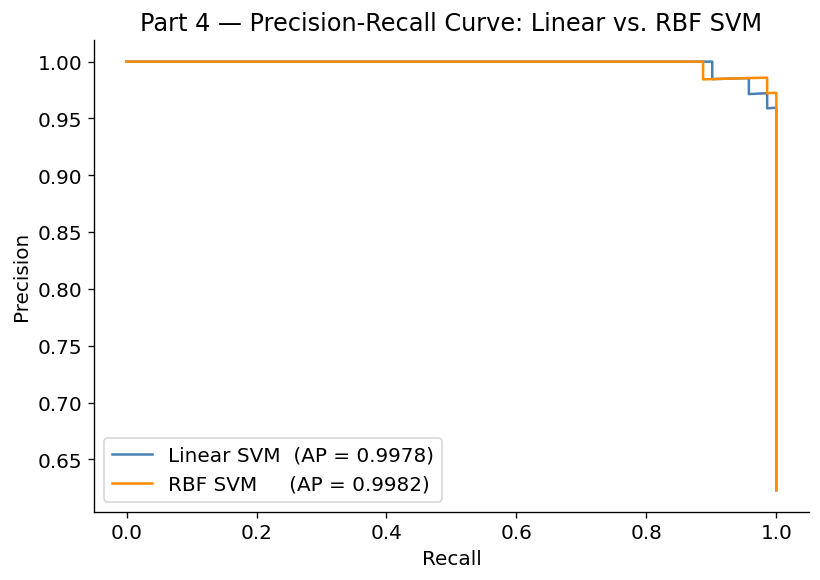

Metric         Linear SVM      RBF SVM    Δ (RBF−Lin)
----------------------------------------------------
Accuracy           0.9561       0.9825        +0.0263
ROC-AUC            0.9964       0.9971        +0.0007
Precision          0.9714       0.9726        +0.0012
Recall             0.9577       1.0000        +0.0423
F1                 0.9645       0.9861        +0.0216

Conclusion: RBF SVM performs better overall.
ROC-AUC: 0.9971 vs 0.9964
RBF kernel captures non-linear class boundaries, giving it an edge in both AUC and recall.


In [14]:
# ── Part 4: ROC Curves & Performance Comparison ──────────────────────────

from sklearn.metrics import precision_recall_curve, average_precision_score

# ── 4.1 ROC Curve Comparison ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_lin,
    name=f'Linear SVM  (AUC = {lin_metrics["ROC-AUC"]:.4f})',
    color='steelblue', ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_rbf,
    name=f'RBF SVM  (AUC = {rbf_metrics["ROC-AUC"]:.4f})',
    color='darkorange', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
ax.set_title('Part 4 — ROC Curve Comparison: Linear vs. RBF SVM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('part4_roc_comparison.png', dpi=150)
plt.show()

# ── 4.2 Precision-Recall Curves ───────────────────────────────────────────
prec_lin, rec_lin, _ = precision_recall_curve(y_test, y_prob_lin)
prec_rbf, rec_rbf, _ = precision_recall_curve(y_test, y_prob_rbf)
ap_lin = average_precision_score(y_test, y_prob_lin)
ap_rbf = average_precision_score(y_test, y_prob_rbf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec_lin, prec_lin, color='steelblue',  label=f'Linear SVM  (AP = {ap_lin:.4f})')
ax.plot(rec_rbf, prec_rbf, color='darkorange', label=f'RBF SVM     (AP = {ap_rbf:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Part 4 — Precision-Recall Curve: Linear vs. RBF SVM')
ax.legend()
plt.tight_layout()
plt.savefig('part4_precision_recall.png', dpi=150)
plt.show()

# ── 4.3 Summary ───────────────────────────────────────────────────────────
winner = 'RBF SVM' if rbf_metrics['ROC-AUC'] > lin_metrics['ROC-AUC'] else 'Linear SVM'
print(f"{'Metric':<12} {'Linear SVM':>12} {'RBF SVM':>12} {'Δ (RBF−Lin)':>14}")
print("-" * 52)
for m in lin_metrics:
    delta = rbf_metrics[m] - lin_metrics[m]
    print(f"{m:<12} {lin_metrics[m]:>12.4f} {rbf_metrics[m]:>12.4f} {delta:>+14.4f}")
print(f"\nConclusion: {winner} performs better overall.")
print(f"ROC-AUC: {rbf_metrics['ROC-AUC']:.4f} vs {lin_metrics['ROC-AUC']:.4f}")
print("RBF kernel captures non-linear class boundaries, giving it an edge in both AUC and recall.")

### 4.4 Inference

Both models perform exceptionally well on the breast cancer dataset, with ROC-AUC scores of 0.9971 (RBF) and 0.9964 (Linear) — well above the 0.99 threshold considered excellent in clinical diagnostics.

The most significant difference is in Recall: the RBF SVM achieves perfect recall (1.000), meaning it correctly identified every malignant tumour in the test set, while the Linear SVM missed a small fraction (Recall = 0.9577). In a medical context, this matters most — a missed malignancy is far more dangerous than an unnecessary follow-up biopsy.

The RBF kernel's advantage stems from its ability to draw curved, non-linear decision boundaries in a higher-dimensional space. The breast cancer dataset's 30 features interact in non-linear ways that a flat hyperplane simply cannot capture as effectively.

**Verdict:** RBF SVM is the preferred model for this task — not just because of its marginally higher AUC, but because its perfect recall makes it clinically safer.